<a href="https://colab.research.google.com/github/vishalcjha/abustub-rs/blob/main/torch/Discover_PI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
## A quick example to show how to import torch.
import torch
## Generate 100 random points
ip_radii  = torch.randn(100)
## Generate corresponding ares
unknowns = torch.pi * (ip_radii ** 2)
torch.set_printoptions(precision=3, sci_mode=False)

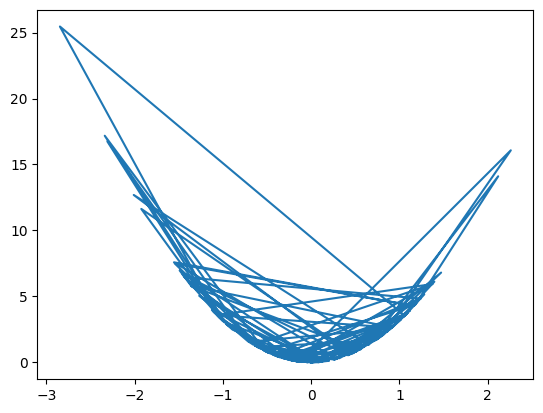

In [10]:
#Plot it using matplotlib
import matplotlib.pyplot as plt
plt.plot(ip_radii.numpy(), unknowns.numpy(), label='Area plot')

In [11]:
# How far prediction is from actual value. There are many ways to calcualte this, one of simple being square mean difference.
def loss_fn(t_p, t_c):
    sq_diff = (t_p - t_c) ** 2
    return sq_diff.mean()


In [12]:
## Model trainig is looping though same set of data over and over again,
## till we have acceptable rate.

## During each iteration, learning parameter, or parameters are updated.
## One hopes to see loss going down overtime.
def training_loop(n_epochs, model, show_loss, learning_rate, params, ip_radii, unknowns):
    for epoch in range(1, n_epochs + 1):
        ## Gradient accumulates. So clear them if they are there.
        if params.grad is not None:
            params.grad.zero_()

        ## Call the model to get prdicated value. This is the forward pass of training loop.
        t_p = model(ip_radii, *params)
        ## Calculate loss
        loss = loss_fn(t_p, unknowns)
        if (epoch % 100 == 0) and show_loss:
            print(loss)
        ## Find the gradient. This is backward pass of training loop, where calculation goes from final result loss,
        ## towards input. This uses chain rule to find derivite of loss over parameters.
        loss.backward()

        ## Update parameters. Here we do not want to accumulate gradient, so no_grad
        with torch.no_grad():
            params -= learning_rate * params.grad

    return (params, loss)

In [13]:
## Some parameters for model running. These are referred as hyper parameters.

## How fast to change parameter. A small value makes model takes long time and a high values makes model jump past optimal solution.
learning_rate = 1e-2
## How many time to run training loop
n_epochs = 1000
## Learning parameters. Look at requires_grad True. Otherwise backward traversal will not give any values.
params = torch.tensor([1., 0.], requires_grad = True)

## Input radiia
ip_radii = torch.randn(100)
## Here we know the anwser or label. This makes is supervised learning.
unknowns = torch.pi * (ip_radii ** 2)

In [14]:
# A simple function.
def linear_model(t_u, w, b):
    return w * t_u + b
prams, loss = training_loop(n_epochs, linear_model, True, learning_rate, params, ip_radii, unknowns)

## As function is too simple for this phenomena, it is not able to capture relationship b/w input and output
print(f"Parameter : {params}, Loss :{loss}")
print(f"pi is {params[0]}")

tensor(16.825, grad_fn=<MeanBackward0>)
tensor(16.580, grad_fn=<MeanBackward0>)
tensor(16.574, grad_fn=<MeanBackward0>)
tensor(16.574, grad_fn=<MeanBackward0>)
tensor(16.574, grad_fn=<MeanBackward0>)
tensor(16.574, grad_fn=<MeanBackward0>)
tensor(16.574, grad_fn=<MeanBackward0>)
tensor(16.574, grad_fn=<MeanBackward0>)
tensor(16.574, grad_fn=<MeanBackward0>)
tensor(16.574, grad_fn=<MeanBackward0>)
Parameter : tensor([-0.216,  3.140], requires_grad=True), Loss :16.57428550720215
pi is -0.21552997827529907


In [15]:
# A bit complex function. Complex function usually capture relationship better, but they also tend to take long time to run.
# Thought I am calling below complex, it is still very simple. Also these model have sinle layer.
def quadratic_model(t_u, w, b):
    return w * (t_u ** 2) + b
prams, loss =  training_loop(n_epochs, quadratic_model, True, learning_rate, params, ip_radii, unknowns)

# We see loss goes to zero after 400 training loop. We could have terminated early.
print(f"Parameter : {params}, Loss :{loss}")

## With loss almost zero, we have discovered PI.
print(f"pi is {params[0]}")

tensor(1.150, grad_fn=<MeanBackward0>)
tensor(0.132, grad_fn=<MeanBackward0>)
tensor(0.015, grad_fn=<MeanBackward0>)
tensor(0.002, grad_fn=<MeanBackward0>)
tensor(0.000, grad_fn=<MeanBackward0>)
tensor(    0.000, grad_fn=<MeanBackward0>)
tensor(    0.000, grad_fn=<MeanBackward0>)
tensor(    0.000, grad_fn=<MeanBackward0>)
tensor(    0.000, grad_fn=<MeanBackward0>)
tensor(    0.000, grad_fn=<MeanBackward0>)
Parameter : tensor([    3.142,     0.000], requires_grad=True), Loss :4.177709733710344e-09
pi is 3.1415557861328125
